In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.helpers.plotting_helper import set_plotting_defaults
from utils import read_ooc

set_plotting_defaults()

In [3]:
dft = read_ooc("dft.csv", material="znpc")
exp = read_ooc("exp.csv", material="znpc")
# crop to 275 eV - 300 eV
dft = dft[(dft["energy"] >= 280) & (dft["energy"] <= 300)]
exp = exp[(exp["energy"] >= 280) & (exp["energy"] <= 300)]


/tmp/ipykernel_2751138/840787210.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


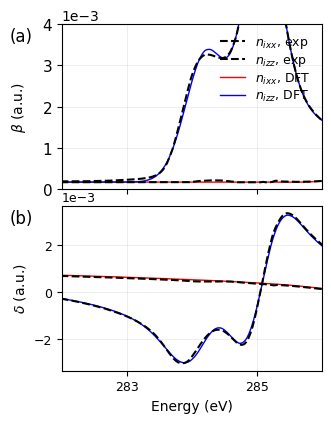

In [12]:
fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[1, 1],
    gridspec_kw={"hspace": 0.1},
    sharex=True,
)

# Plot (a): beta components (Imaginary part, n_ixx and n_izz)
ax1.plot(
    exp["energy"],
    exp["n_ixx"],
    "--",
    label=r"$n_{ixx}$, exp",
    color="black",
    zorder=10
)
ax1.plot(
    exp["energy"],
    exp["n_izz"],
    "--",
    label=r"$n_{izz}$, exp",
    color="black",
    zorder=10
)
ax1.plot(
    dft["energy"],
    dft["n_ixx"],
    "-",
    color="red",
    linewidth=1,
    label=r"$n_{ixx}$, DFT"
)
ax1.plot(
    dft["energy"],
    dft["n_izz"],
    "-",
    color="blue",
    linewidth=1,
    label=r"$n_{izz}$, DFT"
)

# Place (a) label in line with the y-axis label
ax1.set_ylabel(r"$\beta$ (a.u.)")
ax1.set_xlim(283, 295)
ax1.yaxis.offsetText.set_fontsize(10)
ax1.tick_params(axis='both', which='major', labelsize=11)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax1.legend(
    loc="upper right",
    fontsize=9,
    frameon=False,
    labelspacing=0.2
)

# Plot (b): delta components (Real part, n_xx and n_zz)
ax2.plot(
    exp["energy"],
    exp["n_xx"],
    "--",
    label=None,
    color="black",
    zorder=10,
)
ax2.plot(
    exp["energy"],
    exp["n_zz"],
    "--",
    label=None,
    color="black",
    zorder=10,
)
ax2.plot(
    dft["energy"],
    dft["n_xx"],
    "-",
    color="red",
    linewidth=1,
    label=None
)
ax2.plot(
    dft["energy"],
    dft["n_zz"],
    "-",
    color="blue",
    linewidth=1,
    label=None
)
# scientific notation for y axis
ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
# set x-labels to run 283, 285, 287, 289, 291, 293, 295
ax2.set_xticks([283, 285, 287, 289, 291, 293, 295])
ax2.set_xlabel(r"Energy (eV)")
# Place (b) label in line with the y-axis label below
ax2.set_ylabel(r"$\delta$ (a.u.)")

ax1.text(
    -0.20, 0.98, "(a)", transform=ax1.transAxes,
    fontsize=12, va="top", ha="left"
)

ax2.text(
    -0.20, 0.98, "(b)", transform=ax2.transAxes,
    fontsize=12, va="top", ha="left"
)
ax2.set_xlim(282, 286)
ax1.set_ylim(0, 4e-3)

fig.align_labels()
fig.tight_layout()
# save the figure
fig.savefig("Fig1_tensor.png", dpi=300, bbox_inches="tight")